<a href="https://colab.research.google.com/github/2007856reyli/Actividades/blob/main/AF8_RNC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AF8_RNC – Red Neuronal Convolucional

# AF8_RNC
# Hora: V6
# Grupo: 013

# EQUIPO

# Reyli Isaac Morales Zarazua - 2007856
# Ernesto Gerardo Loera Vega - 2101664
# Arturo Gabriel Sandoval Villarreal - 2100680
# Jesus Alexander Guzmán Eguia - 2052987
# Edgar Abraham Padilla Quiroz - 2121425

# Cargar librerías

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt
import numpy as np

# Cargar conjunto de datos MNIST

In [2]:
(train_data, train_labels), (test_data, test_labels) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Mostrar dimensiones del dataset

In [3]:
print("Entrenamiento:", train_data.shape)
print("Prueba:", test_data.shape)

Entrenamiento: (60000, 28, 28)
Prueba: (10000, 28, 28)


# Mostrar una imagen del dataset

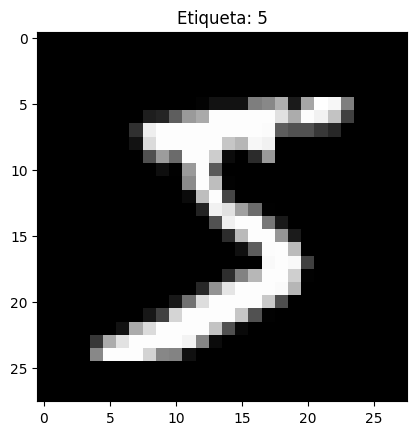

In [4]:
plt.imshow(train_data[0], cmap='gray')

plt.title(f"Etiqueta: {train_labels[0]}")

plt.show()

# Preprocesamiento de datos

Se normalizan las imágenes para mejorar el entrenamiento de la red neuronal.

In [5]:
train_data = train_data / 255.0

test_data = test_data / 255.0

# Ajustar dimensiones para CNN

In [6]:
train_data = train_data.reshape((60000, 28, 28, 1))

test_data = test_data.reshape((10000, 28, 28, 1))

# Creación de la Red Neuronal Convolucional

La arquitectura utilizada incluye:

- Capas convolucionales
- Capas MaxPooling
- Capa Flatten
- Capas Dense
- Función Softmax

In [7]:
model = keras.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dense(
        10,
        activation='softmax'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Mostrar arquitectura del modelo

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

# Compilar modelo

Se utiliza:

- Optimizador Adam
- Función de pérdida sparse_categorical_crossentropy
- Métrica accuracy

In [9]:
model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

# Entrenamiento del modelo

In [10]:
history = model.fit(

    train_data,

    train_labels,

    epochs=10,

    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/step - accuracy: 0.9567 - loss: 0.1422 - val_accuracy: 0.9805 - val_loss: 0.0643
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.9853 - loss: 0.0470 - val_accuracy: 0.9842 - val_loss: 0.0545
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.9903 - loss: 0.0316 - val_accuracy: 0.9859 - val_loss: 0.0523
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.9926 - loss: 0.0230 - val_accuracy: 0.9885 - val_loss: 0.0383
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 30ms/step - accuracy: 0.9942 - loss: 0.0178 - val_accuracy: 0.9893 - val_loss: 0.0394
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9960 - loss: 0.0121 - val_accuracy: 0.9900 - val_loss: 0.0411
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 30ms/step - accuracy: 0.9967 - loss: 0.0102 - val_accuracy: 0.9897 - val_loss: 0.0475
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.9966 -

# Evaluación del modelo

In [11]:
test_loss, test_accuracy = model.evaluate(
    test_data,
    test_labels
)

print("Exactitud:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9876 - loss: 0.0457
Exactitud: 0.9876000285148621


# Predicciones del modelo

Se realizan 5 predicciones utilizando el conjunto de prueba.

In [12]:
predictions = model.predict(test_data)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


# Mostrar 5 predicciones

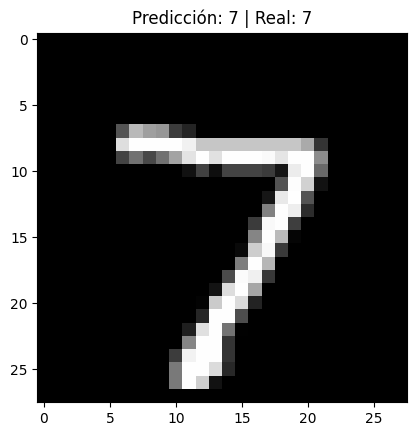

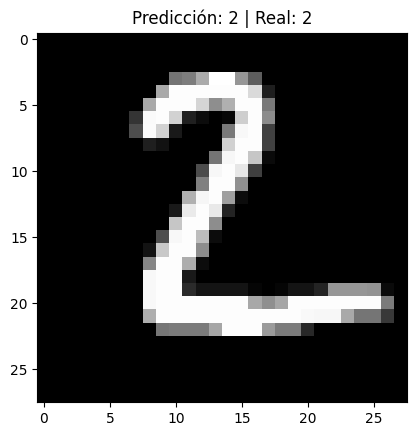

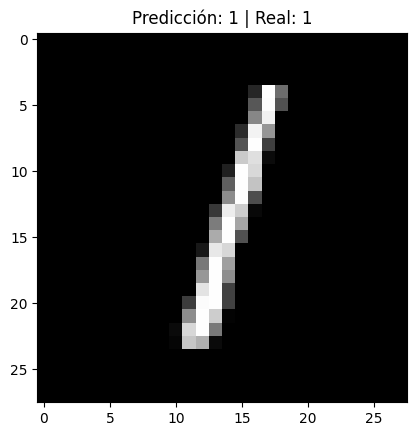

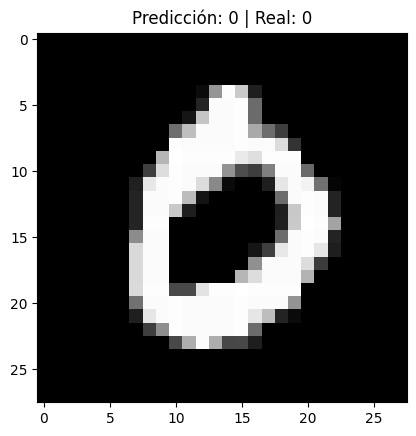

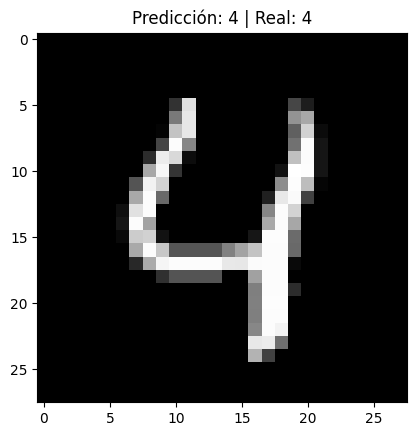

In [13]:
for i in range(5):

    predicted_label = np.argmax(predictions[i])

    real_label = test_labels[i]

    plt.imshow(
        test_data[i].reshape(28,28),
        cmap='gray'
    )

    plt.title(
        f"Predicción: {predicted_label} | Real: {real_label}"
    )

    plt.show()